In [ ]:
################################################################################################################
################################################################################################################
###                       Orthogonal Polynomial Operator Learning with Induced Sampling:
###                                Learn the NS Solution Operator from Data                                       
################################################################################################################
################################################################################################################

################################################################################################################
###                                             Import libraries:
################################################################################################################
import sys
sys.path.insert(0, '../Modules/')

import numpy as np
import torch
from sklearn.decomposition import PCA
from index_set import index_set
#from index_set import bounded_hyperbolic_cross_set
from families import JacobiPolynomials
from HAlphaBasisCompressor import HAlphaBasisCompressor
from OperatorLearningPlotter import OperatorLearningPlotter
from Empirical_Operator_WLS import Empirical_Operator_WLS

### Dimension Reduction parameters
nPCA_Max =  750              # Maximum number of PCA modes allowed
PCA_Threshold = 0.995        # Amount of energy to retain in input space
alpha = 0                    # Sobolev Parameter for output space: 0 = L^2, 1 = H^1, etc.  
HAlpha_Threshold = 0.999     # Amount of energy to retain in output data

### Index set params
max_poly_indx = 10           # Maximum degree of (univariate) polynomial in gPC
N_max = 5000                 # Maximum size of (effective) hyperbolic index set
anisotropic = True           # Weight poly-deg multi-indices by normalized sing val of input dat    

### Scale input data to lie in [-1,1]: 
normalization = 'uniform'    # Scale all input data uniformly, to maintain relative magnitudes

### Load data 
# Spatial data is on 128 x 128 grid
train_dat = torch.load('Spatial_Data/nsforcing_train_128.pt', weights_only=True)
test_dat  = torch.load('Spatial_Data/nsforcing_test_128.pt', weights_only=True )
X_train_grid = train_dat['x'].numpy()
Y_train_grid = train_dat['y'].numpy()
X_test_grid  = test_dat['x'].numpy()
Y_test_grid  = test_dat['y'].numpy()

# Reshape X grid data to vector for PCA
X_train = X_train_grid.reshape(X_train_grid.shape[0],-1)
X_test  = X_test_grid.reshape(X_test_grid.shape[0], -1) 

# Adaptively choose number of PCA coeffcients 
pca = PCA(n_components = nPCA_Max)
pca.fit(X_train)
nPCA_X = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), PCA_Threshold)+1

# Preform PCA to lower dimensionality
pca_X = PCA(n_components=nPCA_X)
input_data_raw = pca_X.fit_transform(X_train)
input_data_raw_test = pca_X.transform(X_test)

# Scale input coefficients to lie in [-1,1] for Jacobi Polynomial Domain 
if normalization == 'uniform':
    linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test))))
    input_data = input_data_raw / linf
    input_test = input_data_raw_test / linf

elif normalization == 'entrywise': 
    input_data = np.zeros_like(input_data_raw)
    input_test = np.zeros_like(input_data_raw_test)
    for col in range(nPCA_X):
        linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test)))[:,col])
        input_data[:,col] = input_data_raw[:,col]/linf
        input_test[:,col] = input_data_raw_test[:,col]/linf
else:
    raise ValueError("Normalization must be either 'uniform' for 'entrywise'")

# Project Y Data onto H^alpha subspace:
compressor = HAlphaBasisCompressor(N=Y_train_grid.shape[1], threshold=HAlpha_Threshold, alpha = alpha)
compressor.fit(Y_train_grid) 
output_data = np.array([compressor.project(snapshot) for snapshot in Y_train_grid])
output_test = np.array([compressor.project(snapshot) for snapshot in Y_test_grid])

### Fit Jacobi Parameters Defining Measure on Input Space by Matching Empirical Variance 
#   NOTE: For symmetric beta distribution, Var_a = 1/(2a + 3)
VarX = np.var(input_data, axis = 0)
VarX_safe = np.clip(VarX, 1e-10, None)  # avoid blow up for near zero variance
jParams = ((1/VarX) - 3)/2   

# Define index set weights
idx_weights = pca_X.singular_values_ / pca_X.singular_values_[0] if anisotropic else np.ones(nPCA_X)


In [ ]:
def cond_G(HC_Param, induced):
    
    PolyIdxs = index_set(d = nPCA_X, param = HC_Param, max_index = max_poly_indx, weights = idx_weights, max_size = N_max, type = 'hc' )
    N = PolyIdxs.shape[0]
    M = int(N*np.log(N))

    wls_operator = Empirical_Operator_WLS(
        input_data = input_data, 
        output_data = output_data, 
        index_set = PolyIdxs, 
        jacobi_params = jParams,
        induced = induced)

    # Fit Operator to Training Data 
    wls_operator.fit(M)
    return N, np.linalg.cond(wls_operator.W)**2

In [ ]:
# Get condition number / (effective) dimension 
runs = 3
Hc = np.array([6,9,12,15,18,21,24])
Dims = np.zeros(Hc.shape[0])
C_Ind = np.zeros((Hc.shape[0], runs))
C_Std = np.zeros((Hc.shape[0], runs))
for h in range(Hc.shape[0]):
    for r in range(runs):
        Dims[h],C_Ind[h,r] = cond_G(Hc[h], True)
        Dims[h], C_Std[h,r] = cond_G(Hc[h], False)

np.save('Data/Condition_Ind.npy', C_Ind)
np.save('Data/Condition_Std.npy', C_Std)
np.save("Data/Condition_Dims.npy", Dims)

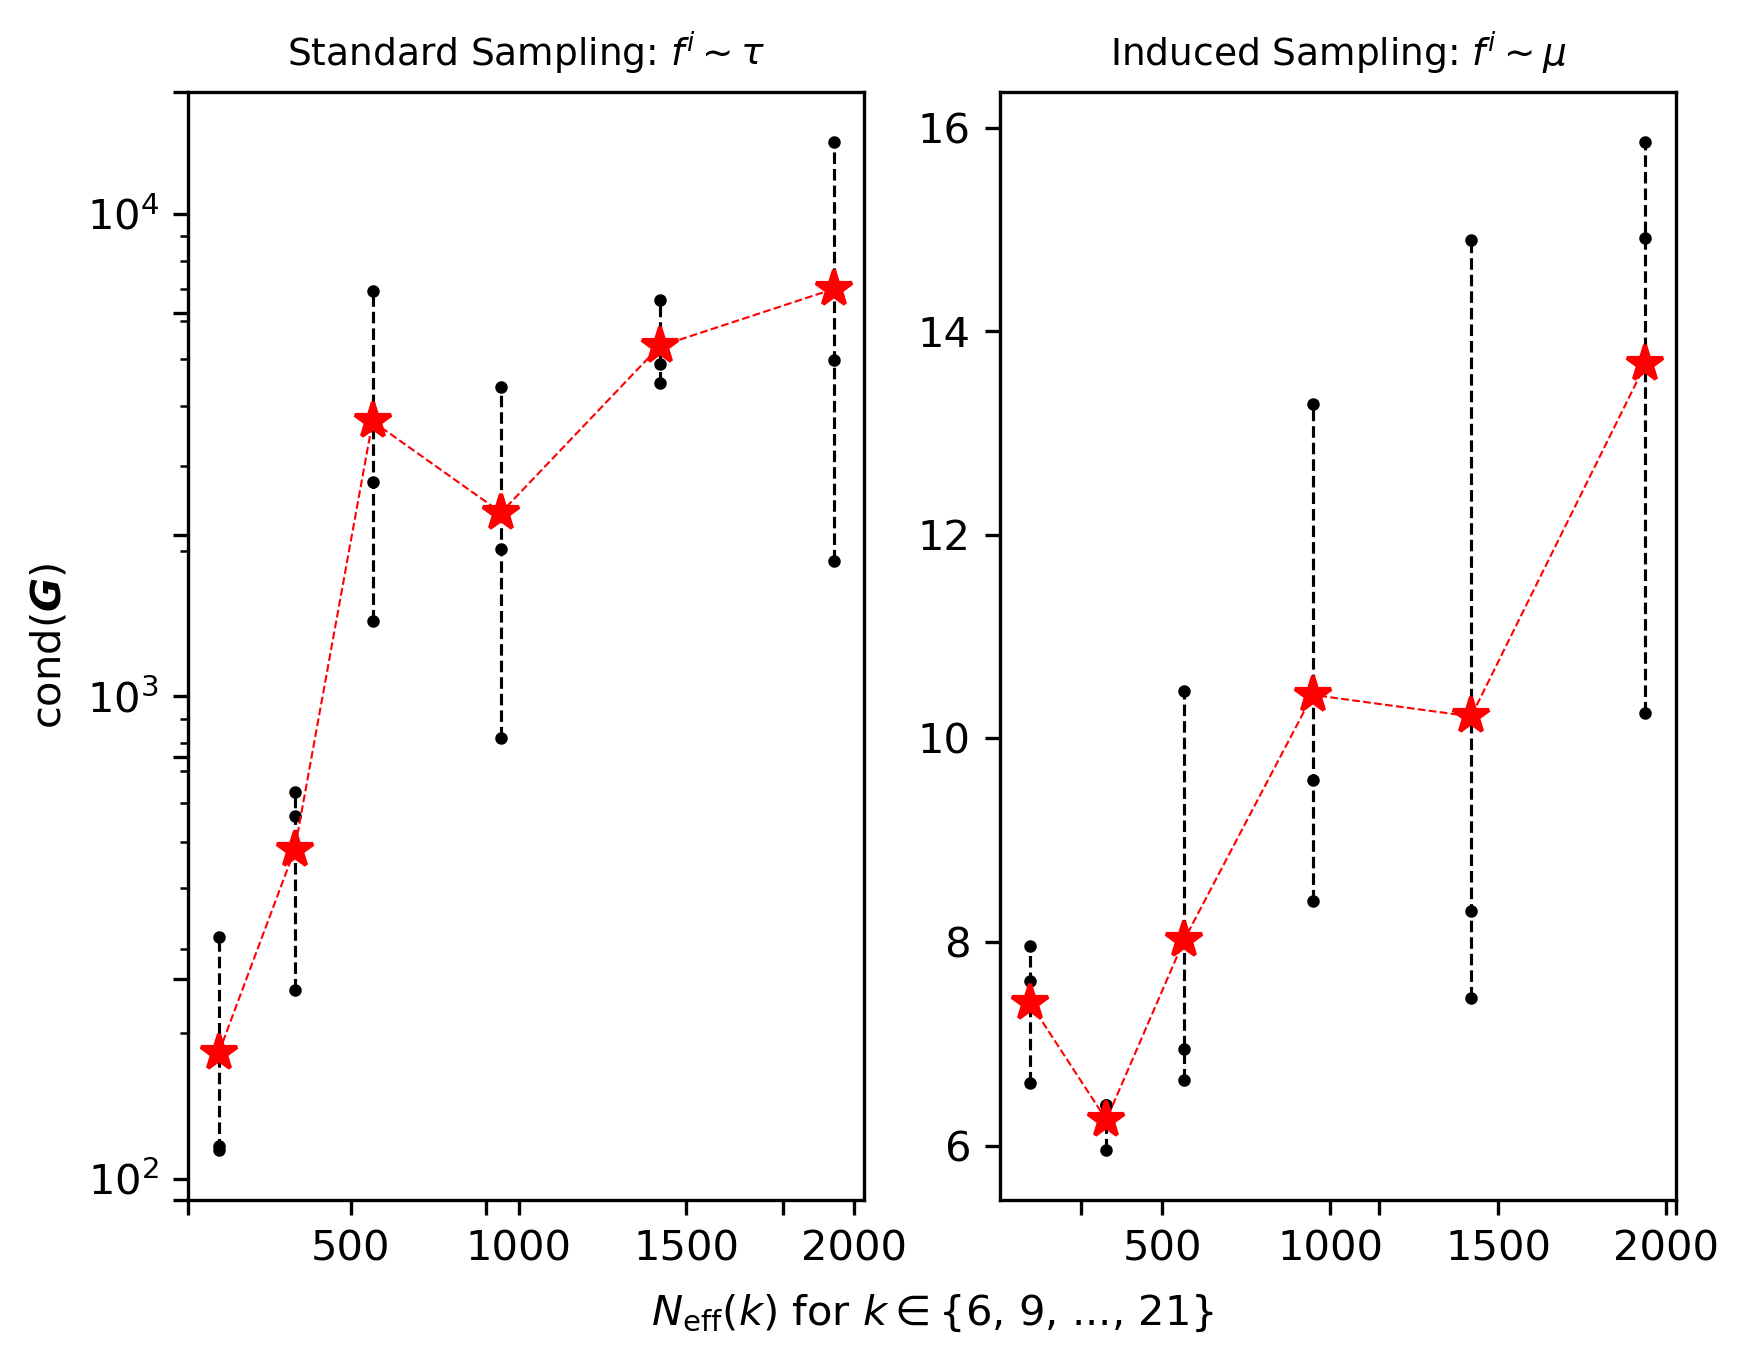

In [1]:
import matplotlib as mpl
import numpy as np
mpl.rcParams['figure.dpi'] = 300
import matplotlib.pyplot as plt 
import seaborn as sns 

runs = 3
Hc = np.array([6,9,12,15,18,21,24])

C_Ind = np.load("Data/Condition_Ind.npy")
C_Std = np.load("Data/Condition_Std.npy")
Dims = np.load("Data/Condition_Dims.npy")

C_Ind = C_Ind[:-1,:]
C_Std = C_Std[:-1,:]
Dims = Dims[:-1]
Hc = Hc[:-1]
 
plt.figure()
plt.box(False)
plt.xlabel("\n"+r"$N_{\mathrm{eff}}(k)$ for $ k\in $" +f"{{{Hc[0]}, {Hc[1]}, ..., {Hc[-1]}}}")
ax = plt.gca()
ax.set_axis_off
ax.set_yticklabels([])
ax.set_xticklabels([])


plt.subplot(121)
plt.title(r"Standard Sampling: $f^i\sim \tau$", fontsize = 9)
ax = plt.gca()
plt.yscale('log')
for h in range(Hc.shape[0]):
    plt.plot(Dims[h]*np.ones(runs), np.linspace(np.min(C_Std[h,:]), np.max(C_Std[h,:]),runs),'k--',linewidth = 0.75)
    for r in range(runs):
        plt.plot(Dims[h],C_Std[h,r],'ko',markersize = 2)
plt.plot(Dims, np.mean(C_Std,axis=1), 'r*--',markersize = 9, linewidth = 0.5)
plt.ylabel(r"$\mathrm{cond}(\boldsymbol{G})$")

plt.subplot(122)
plt.title(r"Induced Sampling: $f^i\sim \mu$", fontsize = 9)
for h in range(Hc.shape[0]):
    plt.plot(Dims[h]*np.ones(runs), np.linspace(np.min(C_Ind[h,:]), np.max(C_Ind[h,:]),runs),'k--',linewidth = 0.75)
    for r in range(runs):
        plt.plot(Dims[h],C_Ind[h,r],'ko',markersize = 2)

plt.plot(Dims, np.mean(C_Ind,axis=1), 'r*--',markersize = 9, linewidth = 0.5)
plt.savefig("Plots/NS_CondNum.pdf")
plt.show()

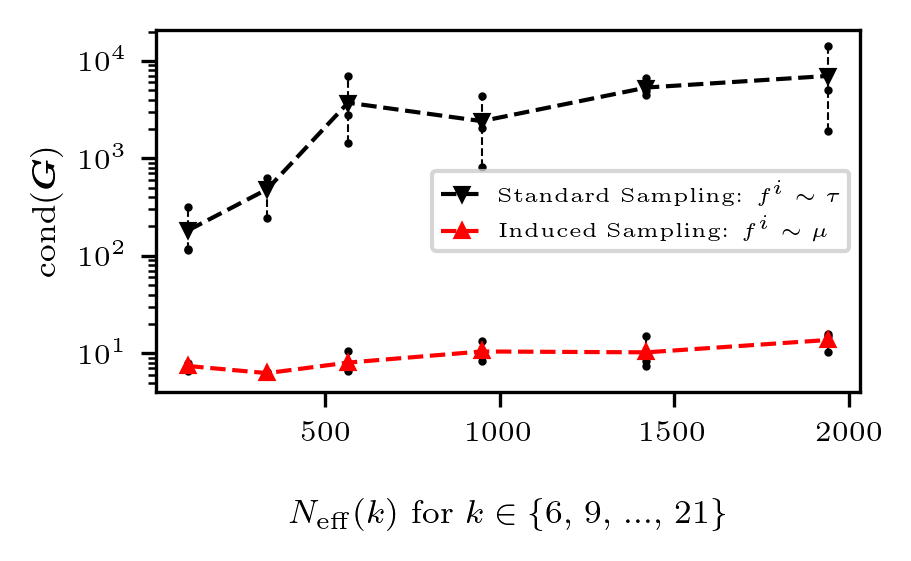

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 0.5
fig_width = textwidth_pt * pt_to_inch   *subfig_ratio         
fig_height = fig_width * 0.6                     
# Font sizes
base = 7  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base + 1      
plt.rcParams["axes.titlesize"] = base + 1      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base -2        
# Markersizes
markersize_small = 1
linewidth_small = 0.5
markersize_large = 3
linewidth_large = 1 


runs = 3
Hc = np.array([6,9,12,15,18,21,24])

C_Ind = np.load("Data/Condition_Ind.npy")
C_Std = np.load("Data/Condition_Std.npy")
Dims = np.load("Data/Condition_Dims.npy")

C_Ind = C_Ind[:-1,:]
C_Std = C_Std[:-1,:]
Dims = Dims[:-1]
Hc = Hc[:-1]


fig,ax = plt.subplots(figsize = (fig_width,fig_height), sharey = True, layout = 'constrained')
ax.set_xlabel("\n"+r"$N_{\mathrm{eff}}(k)$ for $ k\in \{$" +f"{{{Hc[0]}, {Hc[1]}, ..., {Hc[-1]}}}" + r"$\}$")
ax.set_yscale("log")
for h in range(Hc.shape[0]):
    ax.plot(Dims[h]*np.ones(runs), np.linspace(np.min(C_Std[h,:]), np.max(C_Std[h,:]),runs),'k--',linewidth = linewidth_small)
    for r in range(runs):
        ax.plot(Dims[h],C_Std[h,r],'ko',markersize = markersize_small)
ax.plot(Dims, np.mean(C_Std,axis=1), 'kv--',markersize = markersize_large, linewidth = linewidth_large,label =r"Standard Sampling: $f^i\sim \tau$" )
ax.set_ylabel(r"$\mathrm{cond}(\boldsymbol{G})$")

for h in range(Hc.shape[0]):
    ax.plot(Dims[h]*np.ones(runs), np.linspace(np.min(C_Ind[h,:]), np.max(C_Ind[h,:]),runs),'k--',linewidth = linewidth_small)
    for r in range(runs):
        ax.plot(Dims[h],C_Ind[h,r],'ko',markersize = markersize_small)
ax.plot(Dims, np.mean(C_Ind,axis=1), 'r^--',markersize = markersize_large, linewidth = linewidth_large,label = r"Induced Sampling: $f^i\sim \mu$")
ax.legend(loc = 'best')
plt.savefig("Plots/NS_CondNum.pdf")
plt.show()